In [26]:
import numpy as np
import pandas as pd
import warnings
import os
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [8]:
seed = 42

In [12]:
def prepare_sequences_multi(X, y, window_size, horizon):
    X_seq, y_seq = [], []

    for i in range(len(X) - window_size - horizon + 1):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size:i + window_size + horizon])

    return np.array(X_seq), np.array(y_seq)

In [13]:
def build_gru_direct(input_shape: tuple, horizon: int):
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(horizon)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [28]:
def train_gru_multistep_direct(
    X_train,
    y_train,
    X_valid,
    y_valid,
    horizon=10,
    window_size=30,
    epochs=50,
    batch_size=32
):
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_valid_scaled = scaler_X.transform(X_valid)

    y_train_scaled = scaler_y.fit_transform(
        y_train.values.reshape(-1, 1)
    ).reshape(-1)

    y_valid_scaled = scaler_y.transform(
        y_valid.values.reshape(-1, 1)
    ).reshape(-1)

    X_train_seq, y_train_seq = prepare_sequences_multi(
        X_train_scaled, y_train_scaled, window_size, horizon
    )

    X_valid_seq, y_valid_seq = prepare_sequences_multi(
        X_valid_scaled, y_valid_scaled, window_size, horizon
    )

    input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

    model = build_gru_direct(input_shape, horizon)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_valid_seq, y_valid_seq),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        shuffle=False
    )

    return model, scaler_X, scaler_y, history

In [29]:
def forecast_gru_direct(model, val_X, scaler_X, scaler_y, window_size):
    val_scaled = scaler_X.transform(val_X)

    last_window = val_scaled[-window_size:]

    X_input = last_window.reshape(
        1,
        window_size,
        val_scaled.shape[1]
    )

    preds_scaled = model.predict(X_input, verbose=0)

    preds = scaler_y.inverse_transform(
        preds_scaled.reshape(-1, 1)
    ).reshape(preds_scaled.shape)

    return preds.flatten()

In [18]:
# Chargement dataset
def load_wadi_data():
    path = input("Veuillez entrer le chemin complet du fichier CSV : ")
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Base chargée : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
        return df
    else:
        print("Chemin invalide.")
        return None

df = load_wadi_data()

Veuillez entrer le chemin complet du fichier CSV :  C:/Users/abmahamat/Downloads/WADI_clean.csv


Base chargée : 204116 lignes, 124 colonnes.


In [30]:
# Gestion Datetime
if "Datetime" in df.columns:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
    df = df.dropna(subset=["Datetime"])
    
    df = df.sort_values("Datetime")
    df = df.set_index("Datetime")
else:
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df = df.sort_index()

# Régularisation temporelle
df = df.resample("1min").mean(numeric_only=True)
df = df.interpolate().ffill().bfill()

# Cible
target_col = "3_LT_001_PV"

# Toutes les covariables numériques sauf la cible
feature_cols = [
    col for col in df.columns
    if col != target_col
]

# Données modèle
df_model = df[[target_col] + feature_cols].copy()
df_model = df_model.apply(pd.to_numeric, errors="coerce")
df_model = df_model.interpolate().ffill().bfill()

y = df_model[target_col]
X_full = df_model[[target_col] + feature_cols]

In [31]:
train_frac = 0.7
val_frac = 0.15

n_total = len(df_model)

train_end = int(n_total * train_frac)
val_end = int(n_total * (train_frac + val_frac))

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

X_train = X_full.iloc[:train_end]
X_val = X_full.iloc[train_end:val_end]
X_test_full = X_full.iloc[val_end:]

In [32]:
X_test_for_pred = X_test_full.copy()
X_test_for_pred[target_col] = 0    # on évite d’utiliser la vraie cible future

In [33]:
HORIZON = 10
WINDOW_SIZE = 30

model_gru, scaler_X, scaler_y, history = train_gru_multistep_direct(
    X_train=X_train,
    y_train=y_train,
    X_valid=X_val,
    y_valid=y_val,
    horizon=HORIZON,
    window_size=WINDOW_SIZE,
    epochs=50,
    batch_size=32
)

Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0595 - mae: 0.1756 - val_loss: 0.0377 - val_mae: 0.1496 - learning_rate: 0.0010
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0315 - mae: 0.1287 - val_loss: 0.0379 - val_mae: 0.1557 - learning_rate: 0.0010
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0229 - mae: 0.1107 - val_loss: 0.0399 - val_mae: 0.1646 - learning_rate: 0.0010
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0180 - mae: 0.0974 - val_loss: 0.0398 - val_mae: 0.1697 - learning_rate: 0.0010
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0146 - mae: 0.0871 - val_loss: 0.0348 - val_mae: 0.1599 - learning_rate: 0.0010
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0118 - mae: 0.0777 - val_loss: 0.0331 - val_mae: 0.1572 - learning_rate: 0.0010
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0097 - mae: 0.0697 - val_loss: 0.0252 - val_mae: 0.1372 - learning_rate: 0.0010

In [35]:
predictions = forecast_gru_direct(
    model=model_gru,
    val_X=X_val,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    window_size=WINDOW_SIZE
)

In [39]:
X_test_for_pred = X_test_full.copy()
X_test_for_pred[target_col] = 0    # on évite d’utiliser la vraie cible future

In [40]:
y_true = y_test.iloc[:HORIZON].to_numpy().reshape(-1)
y_pred = predictions.reshape(-1)

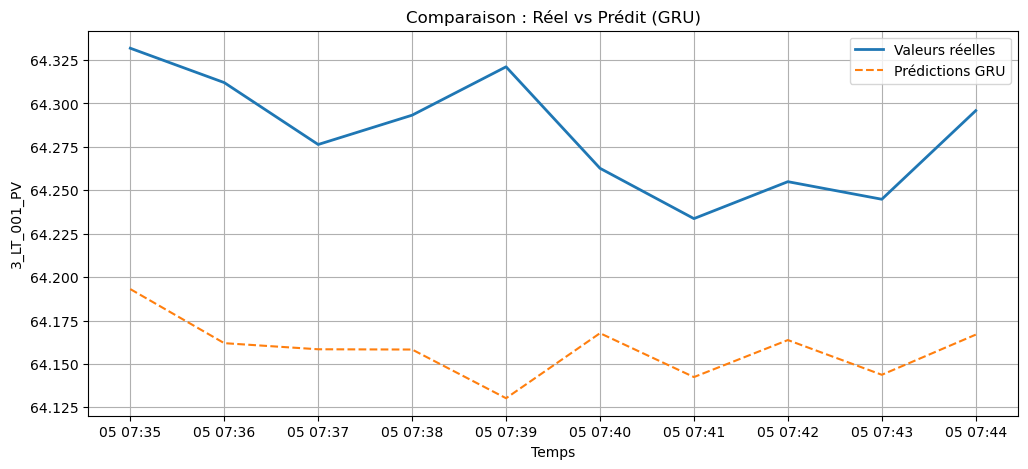

In [42]:
# sécurité alignement
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]
index = y_test.index[:min_len]

plt.figure(figsize=(12,5))

plt.plot(index, y_true, label="Valeurs réelles", linewidth=2)
plt.plot(index, y_pred, label="Prédictions GRU", linestyle="--")

plt.title("Comparaison : Réel vs Prédit (GRU)")
plt.xlabel("Temps")
plt.ylabel("3_LT_001_PV")

plt.legend()
plt.grid()

# qualité haute
plt.savefig("gru_predictions.png", dpi=300, bbox_inches="tight")

plt.show()

In [43]:
# vraies valeurs (10 premières)
y_true = y_test.iloc[:HORIZON].to_numpy().reshape(-1)

# prédictions
y_pred = predictions.reshape(-1)

# métriques
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE :", rmse)
print("MAE :", mae)

RMSE : 0.12760140627031816
MAE : 0.12399980826823054


In [47]:
# vraies valeurs
y_true = y_test.iloc[:HORIZON].to_numpy().reshape(-1)

# prédictions GRU
y_pred = predictions.reshape(-1)

# baseline naïf (persistant)
# on utilise la dernière valeur connue de validation
last_val = y_val.iloc[-1]

baseline = [last_val]

for i in range(1, HORIZON):
    baseline.append(y_true[i-1])  # persistance

baseline = np.array(baseline)

# RMSE
rmse_model = np.sqrt(mean_squared_error(y_true, y_pred))
rmse_baseline = np.sqrt(mean_squared_error(y_true, baseline))

# Skill Score
skill = 1 - (rmse_model / (rmse_baseline + 1e-8))

print("RMSE GRU :", rmse_model)
print("RMSE baseline :", rmse_baseline)
print("Skill Score :", skill)

RMSE GRU : 0.12760140627031816
RMSE baseline : 0.04889245442202528
Skill Score : -1.6098378917638634
